In [2]:
#Name: Pavani Chavali
#Course: Advanced Big Data and Data Mining
#Assignment: Lab 3 – Exploring K-Means and K-Medoids Clustering

In [5]:
!mamba install pandas
!mamba install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import pairwise_distances # Added for our custom K-Medoids
import warnings

warnings.filterwarnings('ignore')

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.865 seconds
All requested packages already installed.
mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 0.870 seconds
All requested packages already installed.


In [9]:
############ STEP:1 ##############
# 1. Load the Wine Dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target # Kept strictly for external validation (ARI calculation)

# 2. Basic Data Exploration
print("--- Data Exploration ---")
print(f"Dataset Dimensions: {X.shape[0]} instances, {X.shape[1]} features.")
display(X.head())

--- Data Exploration ---
Dataset Dimensions: 178 instances, 13 features.


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [7]:
print("\nGround Truth Class Distribution:")
class_distribution = pd.Series(y).value_counts().sort_index()
for label, count in class_distribution.items():
    print(f"Cultivar {label} ({wine.target_names[label]}): {count} instances")


Ground Truth Class Distribution:
Cultivar 0 (class_0): 59 instances
Cultivar 1 (class_1): 71 instances
Cultivar 2 (class_2): 48 instances


In [8]:
# 3. Standardize the dataset using Z-score normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
############ STEP:2 ##############
# Instantiate and fit the K-Means model
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Calculate internal and external validation metrics
kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y, kmeans_labels)

print("--- K-Means Clustering Performance ---")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmeans_ari:.4f}")

--- K-Means Clustering Performance ---
Silhouette Score: 0.2849
Adjusted Rand Index (ARI): 0.8975


In [11]:
############ STEP:3 ##############
class CustomKMedoids:
    """A pure Python implementation of K-Medoids to ensure WebAssembly compatibility."""
    def __init__(self, n_clusters=3, max_iter=100, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state

    def fit_predict(self, X):
        rng = np.random.RandomState(self.random_state)
        
        # 1. Randomly initialize medoids from existing data points
        medoid_indices = rng.choice(len(X), self.n_clusters, replace=False)
        self.cluster_centers_ = X[medoid_indices]

        # 2. Compute the full pairwise Euclidean distance matrix
        D = pairwise_distances(X, metric='euclidean')

        for _ in range(self.max_iter):
            # Assign each point to the closest medoid
            labels = np.argmin(D[:, medoid_indices], axis=1)
            new_medoid_indices = np.copy(medoid_indices)
            
            # Update medoids
            for i in range(self.n_clusters):
                cluster_points_idx = np.where(labels == i)[0]
                if len(cluster_points_idx) == 0:
                    continue
                
                # Find the point that minimizes the distance to all other points in this specific cluster
                cluster_D = D[np.ix_(cluster_points_idx, cluster_points_idx)]
                costs = np.sum(cluster_D, axis=1)
                best_idx_in_cluster = np.argmin(costs)
                new_medoid_indices[i] = cluster_points_idx[best_idx_in_cluster]

            # Convergence check: stop if medoids have not changed
            if np.array_equal(medoid_indices, new_medoid_indices):
                break
            medoid_indices = new_medoid_indices

        self.cluster_centers_ = X[medoid_indices]
        self.labels_ = labels
        return labels

# Instantiate and fit using the Custom K-Medoids model
kmedoids = CustomKMedoids(n_clusters=3, random_state=42)
kmedoids_labels = kmedoids.fit_predict(X_scaled)

# Calculate internal and external validation metrics
kmedoids_silhouette = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y, kmedoids_labels)

print("--- K-Medoids Clustering Performance ---")
print(f"Silhouette Score: {kmedoids_silhouette:.4f}")
print(f"Adjusted Rand Index (ARI): {kmedoids_ari:.4f}")

--- K-Medoids Clustering Performance ---
Silhouette Score: 0.1548
Adjusted Rand Index (ARI): 0.3413


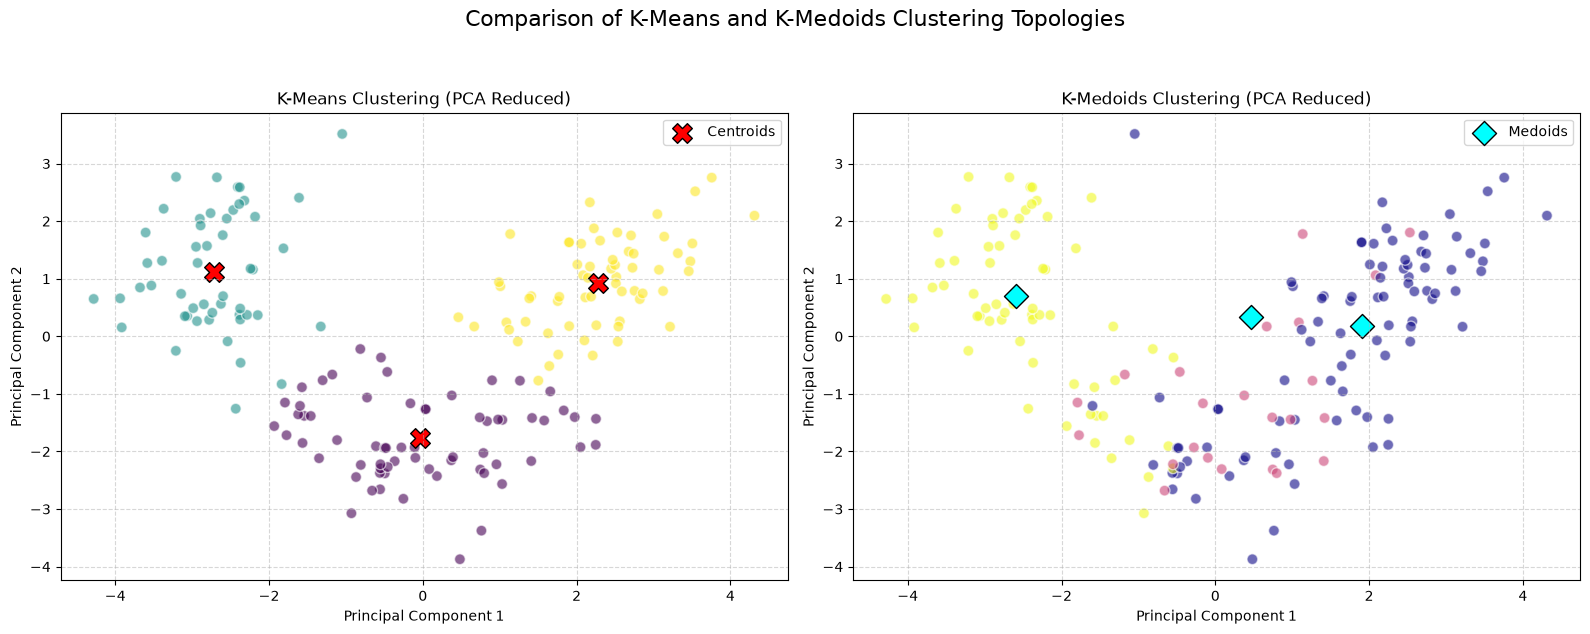

In [12]:
############ STEP:4 ##############
# Reduce dimensions to 2D for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Transform the cluster centers to the new 2D PCA space
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
kmedoids_centers_pca = pca.transform(kmedoids.cluster_centers_)

# Initialize side-by-side plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot K-Means
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, edgecolors='w', s=60)
ax1.scatter(kmeans_centers_pca[:, 0], kmeans_centers_pca[:, 1], c='red', marker='X', s=200, label='Centroids', edgecolors='black')
ax1.set_title('K-Means Clustering (PCA Reduced)')
ax1.set_xlabel('Principal Component 1')
ax1.set_ylabel('Principal Component 2')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot K-Medoids
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels, cmap='plasma', alpha=0.6, edgecolors='w', s=60)
ax2.scatter(kmedoids_centers_pca[:, 0], kmedoids_centers_pca[:, 1], c='cyan', marker='D', s=150, label='Medoids', edgecolors='black')
ax2.set_title('K-Medoids Clustering (PCA Reduced)')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Comparison of K-Means and K-Medoids Clustering Topologies', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()